# Klasyfikacja drzewami decyzyjnymi i lasami losowymi: przycinanie, interpretowalność, k-NN


In [22]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [23]:
from sklearn.datasets import fetch_openml, load_iris

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,f1_score, accuracy_score, roc_auc_score, RocCurveDisplay, precision_recall_curve, PrecisionRecallDisplay

### Wczytanie danych

In [24]:
dataset_name = "adult"
ds = fetch_openml(name=dataset_name, version=2, as_frame=True)
df = ds.frame.copy()
df["income"] = (df['class'] == ">50K").astype(int)
df = df.drop(columns=["class"])
target_col = "income"
df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0


### Wstępna analiza EDA

In [25]:
df.shape

(48842, 15)

In [26]:
df.isnull().sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64

In [27]:
df['income'].value_counts()

income
0    37155
1    11687
Name: count, dtype: int64

In [28]:
info = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isnull().sum(),
    'missing_%': (df.isnull().sum() / len(df)*100).round(2),
    #unique
})

In [29]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop(target_col).tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Numeric   ({len(num_cols)}): {num_cols}")
print(f"Categoric   ({len(cat_cols)}): {cat_cols}")

Numeric   (6): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categoric   (8): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [30]:
df[num_cols].describe().round(2)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.00,48842.00,48842.00,48842.00,48842.0,48842.00
mean,38.64,189664.13,10.08,1079.07,87.5,40.42
std,13.71,105604.03,2.57,7452.02,403.0,12.39
min,17.00,12285.00,1.00,0.00,0.0,1.00
25%,28.00,117550.50,9.00,0.00,0.0,40.00
50%,37.00,178144.50,10.00,0.00,0.0,40.00
75%,48.00,237642.00,12.00,0.00,0.0,45.00
max,90.00,1490400.00,16.00,99999.00,4356.0,99.00


C:\Users\kinga\AppData\Local\Temp\ipykernel_20248\2601550535.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
C:\Users\kinga\AppData\Local\Temp\ipykernel_20248\2601550535.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
C:\Users\kinga\AppData\Local\Temp\ipykernel_20248\2601550535.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
C:\Users\kinga\AppData\Local\Temp\ipykernel_20248\2601550535.py:5: FutureWarning: The defau

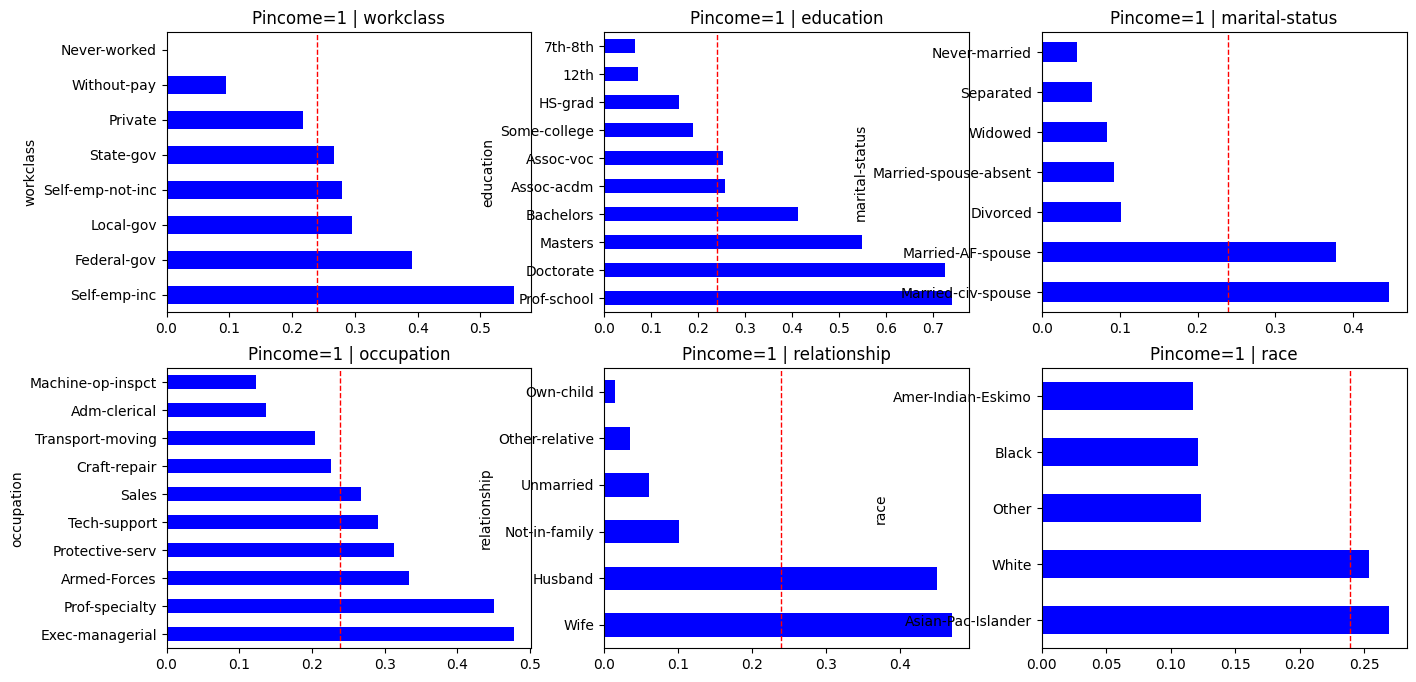

In [31]:
if cat_cols:
    fig, axes = plt.subplots(2, min(3, len(cat_cols)), figsize=(16,8))
    axes = np.array(axes).ravel()
    for i, c in enumerate(cat_cols[:6]):
        vc = df.groupby(c)[target_col].mean().sort_values(ascending=False).head(10)
        vc.plot(kind='barh', ax=axes[i], color='blue', ls='--', lw=1)
        axes[i].axvline(df[target_col].mean(), color='red', ls='--', lw=1)
        axes[i].set_title(f"P{target_col}=1 | {c}")
        axes[i].set_xlabel('')
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout; plt.show()

## Decision Tree

### Pipeline

In [32]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])
preproc = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
], remainder='drop')

feature_names = num_cols + cat_cols
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, {y_train.shape} | Test: {X_test.shape}, {y_test.shape}")
print(f"Rozkład klas w zbiorze treningowym:\n{y_train.value_counts(normalize=True)}")

Train: (24421, 14), (24421,) | Test: (24421, 14), (24421,)
Rozkład klas w zbiorze treningowym:
income
0    0.760698
1    0.239302
Name: proportion, dtype: float64


### Drzewo bazowe + walidacja krzyżowa

In [33]:
base_pipe = Pipeline([
    ('preproc', preproc),
    ('clf', DecisionTreeClassifier(random_state=42))
])

base_pipe.fit(X_train, y_train)
print(f"Pełne drzewo: głębokość: {base_pipe.named_steps['clf'].get_depth()}, liście: {base_pipe.named_steps['clf'].get_n_leaves()}")
print(f"Trening Accuracy: {base_pipe.score(X_train, y_train):.4f}")
print(f"Test Accuracy: {base_pipe.score(X_test, y_test):.4f}")

Pełne drzewo: głębokość: 42, liście: 3573
Trening Accuracy: 0.9999
Test Accuracy: 0.8139


In [34]:
# cv over max depths
depths = list(range(1, 21))
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = []

for d in depths:
    pipe = Pipeline([
        ('preproc', preproc),
        ('clf', DecisionTreeClassifier(max_depth=d, random_state=42))
    ])
    s = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='balanced_accuracy', n_jobs=-1)
    cv_scores.append((s.mean(), s.std()))

cv_df = pd.DataFrame(cv_scores, columns=['mean', 'std'], index=depths)
best_depth = cv_df['mean'].idxmax()
print(f"Najlepsza głębokość: {best_depth}, z wynikiem (Accuracy +- std) {cv_df.loc[best_depth, 'mean']:.4f} ± {cv_df.loc[best_depth, 'std']:.4f}")

Najlepsza głębokość: 10, z wynikiem (Accuracy +- std) 0.7691 ± 0.0156


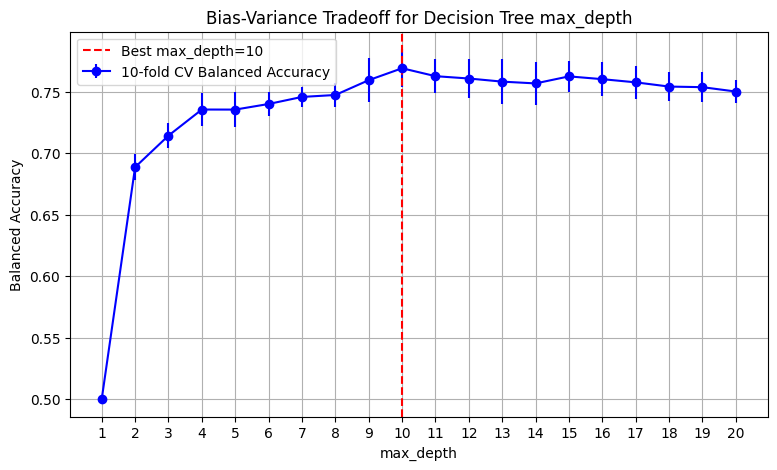

In [35]:
# wykres bias-variance
fig, ax = plt.subplots(figsize=(9,5))
ax.errorbar(cv_df.index, cv_df['mean'], yerr=cv_df['std'], fmt='-o', color='blue', label='10-fold CV Balanced Accuracy')
ax.axvline(best_depth, color='red', ls='--', label=f'Best max_depth={best_depth}')
ax.set_xlabel('max_depth')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('Bias-Variance Tradeoff for Decision Tree max_depth')
plt.grid()
ax.legend()
ax.set_xticks(depths)
plt.show()

###  Cost-Complexity Pruning

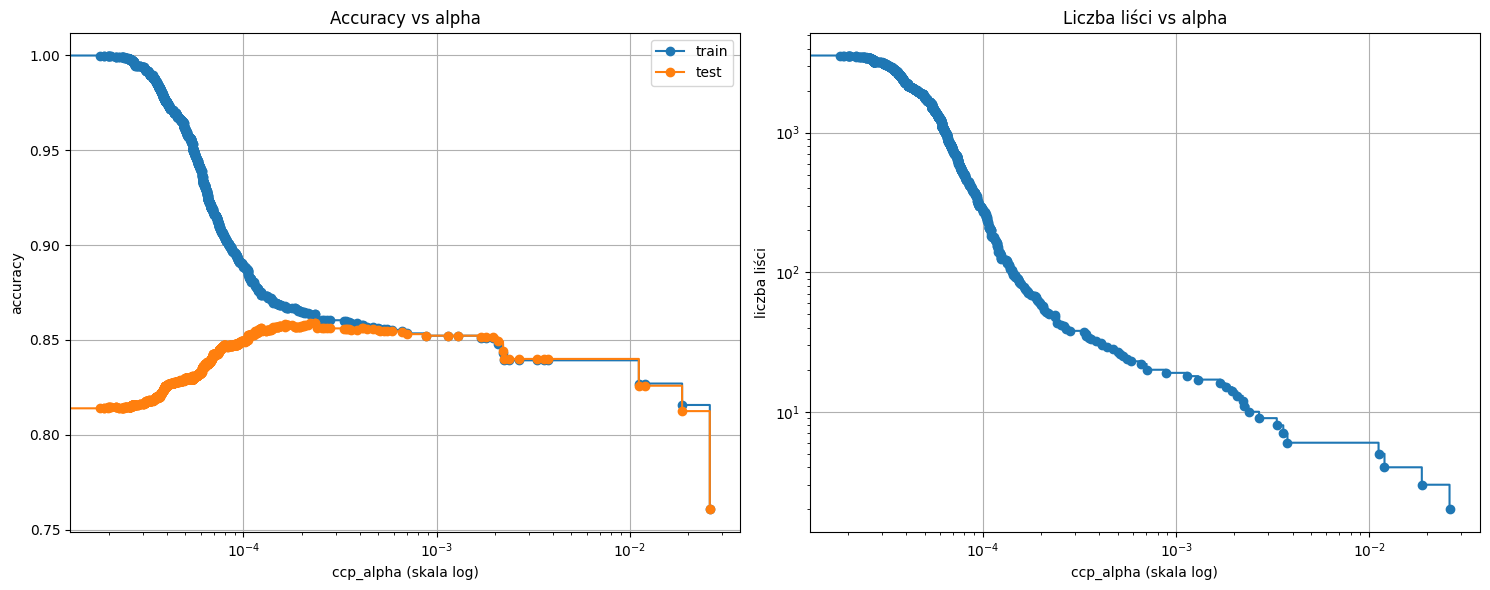

In [36]:
X_train_preproc = preproc.fit_transform(X_train)
X_test_preproc = preproc.transform(X_test)

full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train_preproc, y_train)

path = full_tree.cost_complexity_pruning_path(X_train_preproc, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
ccp_alphas = ccp_alphas[:-1]

clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train_preproc, y_train)
    clfs.append(clf)

train_scores = [clf.score(X_train_preproc, y_train) for clf in clfs]
test_scores = [clf.score(X_test_preproc, y_test) for clf in clfs]
leaf_counts = [clf.get_n_leaves() for clf in clfs]

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# accuracy vs alpha
ax[0].plot(ccp_alphas, train_scores, marker='o', label="train", drawstyle="steps-post")
ax[0].plot(ccp_alphas, test_scores, marker='o', label="test", drawstyle="steps-post")
ax[0].set_xlabel("ccp_alpha (skala log)")
ax[0].set_ylabel("accuracy")
ax[0].set_title("Accuracy vs alpha")
ax[0].set_xscale('log')
ax[0].legend()
ax[0].grid(True)

# number of leaves vs alpha
ax[1].plot(ccp_alphas, leaf_counts, marker='o', drawstyle="steps-post")
ax[1].set_xlabel("ccp_alpha (skala log)")
ax[1].set_ylabel("liczba liści")
ax[1].set_title("Liczba liści vs alpha")
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].grid(True)

plt.tight_layout()
plt.show()

Wykres "Accuracy vs alpha" pokazuje zdolność modelu do generalizacji.
- lewa strona wykresu: drzewo pełne, duży overfitting
- środkowa część wykresu: "złoty środek", taka sama dokładność na zbiorze testowym i treningowym
- prawa strona wykresu: drzewo zbyt proste, underfitting

Wykres "Liczba liści vs alpha" pokazuje jak spada złożoność drzewa (jego liczba liści) w zależności od alpha

In [37]:
alphas_to_test = ccp_alphas[::5] # dla szybkości 

pipe_ccp = Pipeline([
    ('preproc', preproc),
    ('dt', DecisionTreeClassifier(random_state=42))
])

param_grid = {'dt__ccp_alpha': alphas_to_test}
grid_search_ccp = GridSearchCV(
    pipe_ccp, 
    param_grid, 
    cv=10, 
    scoring='balanced_accuracy', 
    n_jobs=-1
)
grid_search_ccp.fit(X_train, y_train)
best_alpha_star = grid_search_ccp.best_params_['dt__ccp_alpha']
print(f"Optymalne alpha*: {best_alpha_star}")
print(f"Najlepszy wynik (CV balanced_accuracy): {grid_search_ccp.best_score_:.4f}")

Optymalne alpha*: 0.000281734734188379
Najlepszy wynik (CV balanced_accuracy): 0.7744


### Porównanie strategii regularyzacji

In [38]:
def get_model_metrics(model, name, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    tree = model.named_steps['dt']
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    f1 = f1_score(y_test, y_test_pred, pos_label=model.classes_[1]) 
    
    return {
        'Model': name,
        'Głębokość': tree.get_depth(),
        'Liczba liści': tree.get_n_leaves(),
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy': round(test_acc, 4),
        'F1 Score (test)': round(f1, 4),
        'Overfit Gap': round(train_acc - test_acc, 4)
    }

models_to_compare = [
    (Pipeline([('preproc', preproc), ('dt', DecisionTreeClassifier(random_state=42))]), 
     "Pełne drzewo"),
    
    (Pipeline([('preproc', preproc), ('dt', DecisionTreeClassifier(max_depth=best_depth, random_state=42))]), 
     f"Pre-pruning (max_depth={best_depth})"),
    
    (Pipeline([('preproc', preproc), ('dt', DecisionTreeClassifier(max_depth=10, 
                                                                    min_samples_leaf=20, 
                                                                    min_impurity_decrease=1e-4, 
                                                                    random_state=42))]), 
     "Pre-pruning kombinowane"),
    
    (Pipeline([('preproc', preproc), ('dt', DecisionTreeClassifier(ccp_alpha=best_alpha_star, random_state=42))]), 
     f"Post-pruning (alpha={best_alpha_star:.5f})")
]

results = []
for model_pipe, name in models_to_compare:
    results.append(get_model_metrics(model_pipe, name, X_train, y_train, X_test, y_test))

comparison_df = pd.DataFrame(results)
display(comparison_df)

,Model,Głębokość,Liczba liści,Train Accuracy,Test Accuracy,F1 Score (test),Overfit Gap
0,Pełne drzewo,42,3573,0.9999,0.8139,0.6132,0.1860
1,Pre-pruning (max_depth=10),10,270,0.8707,0.8523,0.6765,0.0184
2,Pre-pruning kombinowane,10,75,0.8615,0.8541,0.6722,0.0074
3,Post-pruning (alpha=0.00028),10,38,0.8604,0.8561,0.6784,0.0043


Wybrałabym model post-pruning, poniważ przy najmniejszej złożoności uzyskał najlepsze rezultaty

### Wizualizacje drzew

In [39]:
import graphviz
import dtreeviz


tree_depth3 = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_depth3.fit(X_train_preproc, y_train)

feature_names = preproc.get_feature_names_out()
class_names = [str(c) for c in tree_depth3.classes_]

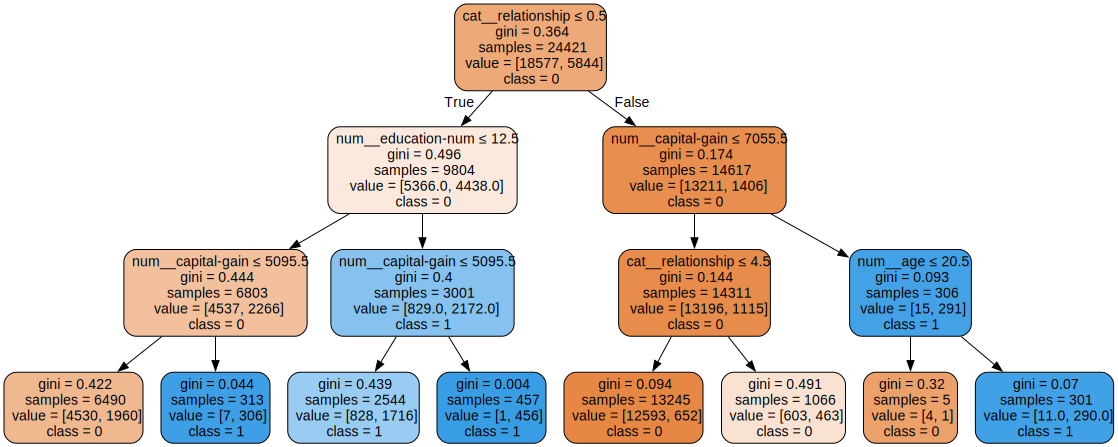

In [40]:
dot_data = export_graphviz(
    tree_depth3, 
    out_file=None, 
    feature_names=feature_names,  
    class_names=class_names,  
    filled=True, 
    rounded=True,  
    special_characters=True
)  
graph = graphviz.Source(dot_data)  
graph

In [41]:
import os
graphviz_path = r'C:\Program Files\Graphviz\bin'

if graphviz_path not in os.environ["PATH"]:
    os.environ["PATH"] += os.pathsep + graphviz_path

dot_path = os.path.join(graphviz_path, 'dot.exe')
if os.path.exists(dot_path):
    print("sukces", graphviz_path)
else:
    print("nie znaleziono")

sukces C:\Program Files\Graphviz\bin


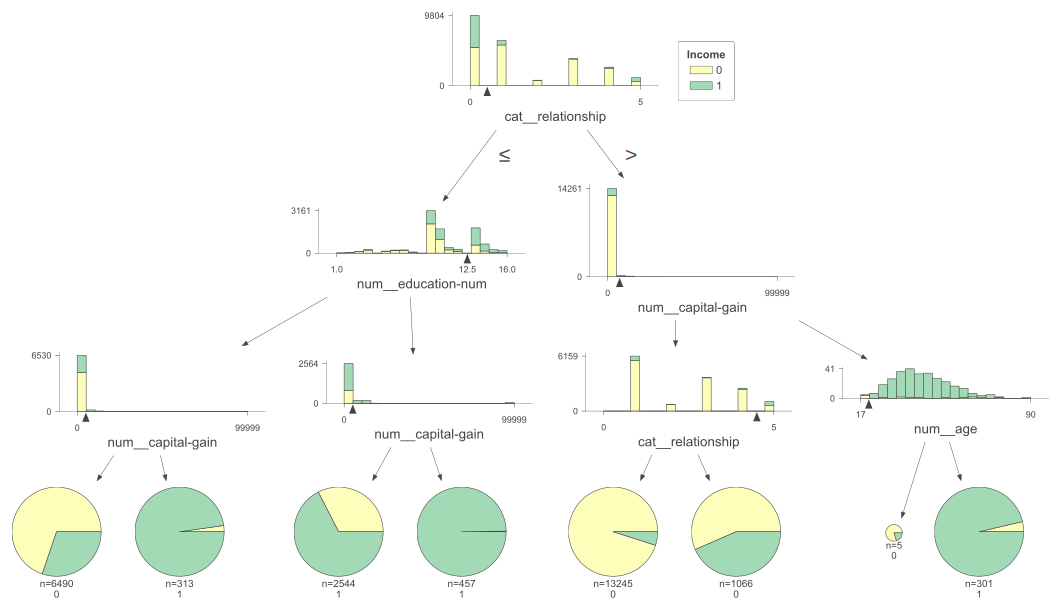

In [ ]:
viz_model = dtreeviz.model(
    tree_depth3,
    X_train_preproc,
    y_train,
    target_name="Income",
    feature_names=list(feature_names),
    class_names=[str(c) for c in tree_depth3.classes_]
)

# Wyświetlenie wizualizacji
v = viz_model.view(scale=1.5)
display(v)

- Wykres Graphviz jest prostszy, przypomina drzewo. Przydaje się jako podstawowa wizualizacja drzewa.
- Wykres Dtreeviz jest bardziej zaawansowany, zawiera w sobie rozkłady cech w każdym węźle w formie histogramów, oraz pie charts w liściach.

### Interpretowalność (built-in, permutation_importance, SHAP)

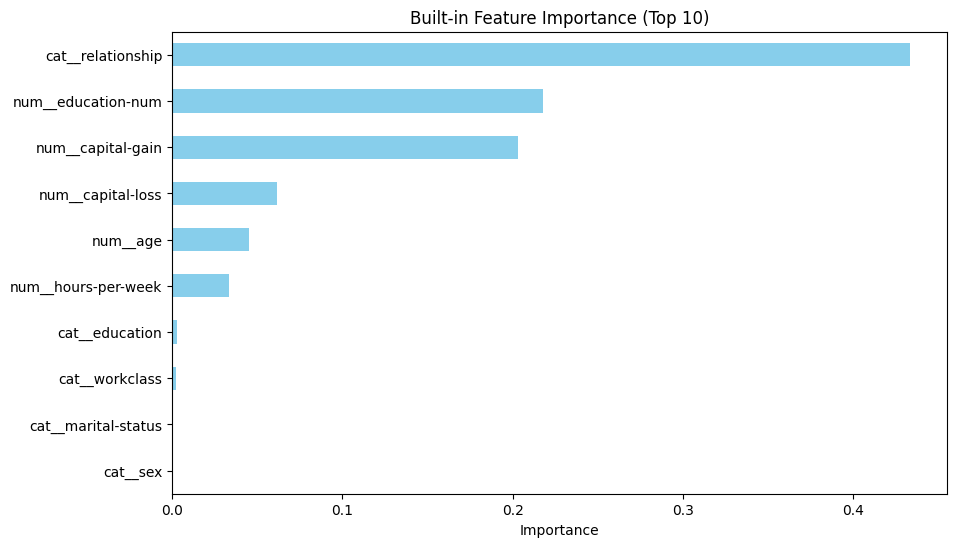

In [44]:
import shap
best_model = grid_search_ccp.best_estimator_
tree_model = best_model.named_steps['dt']
feature_names = preproc.get_feature_names_out()
X_test_preproc_df = pd.DataFrame(
    preproc.transform(X_test), 
    columns=feature_names
)

# Built-in Feature Importance
importances = pd.Series(tree_model.feature_importances_, index=feature_names)
importances_sorted = importances.sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
importances_sorted.plot(kind='barh', color='skyblue')
plt.title("Built-in Feature Importance (Top 10)")
plt.xlabel("Importance")
plt.show()

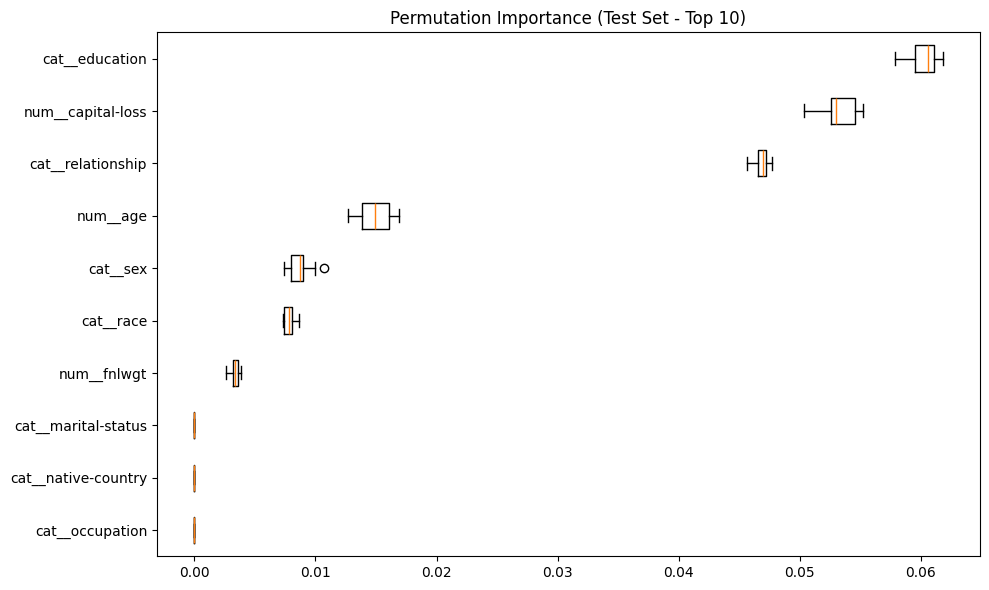

In [46]:
# Permutation Importance
perm_importance = permutation_importance(
    best_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

perm_sorted_idx = perm_importance.importances_mean.argsort()[-10:]
plt.figure(figsize=(10, 6))
plt.boxplot(perm_importance.importances[perm_sorted_idx].T, 
            vert=False, tick_labels=feature_names[perm_sorted_idx])
plt.title("Permutation Importance (Test Set - Top 10)")
plt.tight_layout()
plt.show()

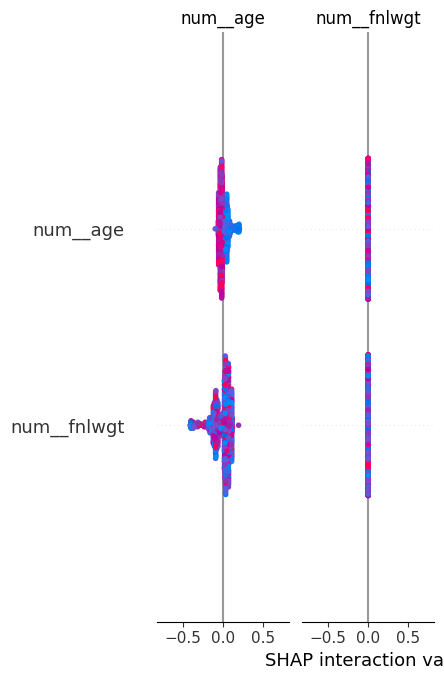

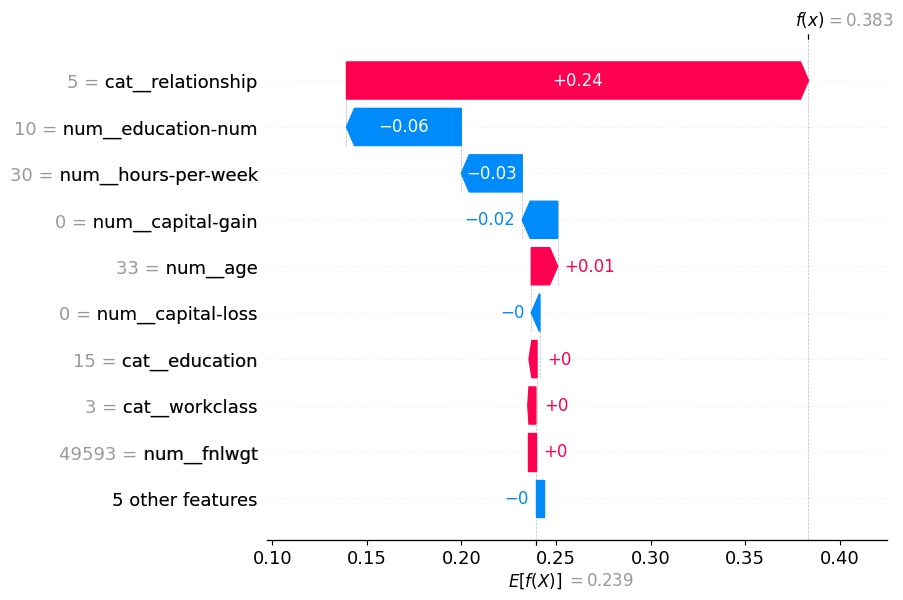

In [47]:
# SHAP
X_sample = X_test_preproc_df.sample(1000, random_state=42)
explainer = shap.TreeExplainer(tree_model)
shap_values = explainer(X_sample)

shap.summary_plot(shap_values, X_sample)
shap.plots.waterfall(shap_values[0, :, 1])

- Built-in Importance: Pokazuje, które cechy najskuteczniej "czyszczą" węzły wewnątrz drzewa.
- Permutation Importance: Bardziej wiarygodna, bo mierzy realny spadek jakości modelu po "zepsuciu" danej cechy. Jeśli cecha jest ważna, jej wymieszanie drastycznie obniży wynik testowy.
- SHAP: Najbardziej zaawansowana. Nie tylko mówi, co jest ważne, ale też w jakim kierunku działa i jak cechy ze sobą współpracują.

- Gini/SHAP oceniają, co model uznał za ważne podczas nauki.
- Permutation Importance ocenia, co faktycznie działa na nowych danych.

Rankingi cech wykazują niespójność. Metody Built-in Importance oraz SHAP wskazują na cechy, których model najbardziej używał podczas budowy struktury drzewa.
Permutation Importance na zbiorze testowym ocenia przydatność cech do generalizacji. Różnice wynikają prawdopodobnie z korelacji między cechami, ponieważ w metodzie permutacyjnej wymieszanie jednej z nich nie powoduje drastycznego spadku jakości, bo model może czerpać te same informacje z innej cechy, co sztucznie obniża jej rangę w tym konkretnym rankingu.

Według wszystkich 3 metod, najważniejsze cechy to education i relationship

### Fairness audit

In [48]:
from sklearn.metrics import confusion_matrix
y_pred = grid_search_ccp.best_estimator_.predict(X_test)

fairness_df = X_test[['sex', 'race']].copy()
fairness_df['target'] = y_test.values
fairness_df['pred'] = y_pred

def get_fairness_metrics(df, group_col):
    metrics = []
    groups = df[group_col].unique()
    
    for group in groups:
        sub = df[df[group_col] == group]
        tn, fp, fn, tp = confusion_matrix(sub['target'], sub['pred'], labels=[0, 1]).ravel()
        selection_rate = (tp + fp) / len(sub)
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        acc = (tp + tn) / len(sub)
        
        metrics.append({
            'Podgrupa': group,
            'Accuracy': round(acc, 4),
            'Selection Rate (Demographic Parity)': round(selection_rate, 4),
            'True Positive Rate (TPR)': round(tpr, 4),
            'False Positive Rate (FPR)': round(fpr, 4)
        })
        
    return pd.DataFrame(metrics).set_index('Podgrupa')

# 3. Analiza dla płci i rasy
print("Fairness: PŁEĆ")
display(get_fairness_metrics(fairness_df, 'sex'))

print("\nFairness: RASA")
display(get_fairness_metrics(fairness_df, 'race'))

Fairness: PŁEĆ


,Accuracy,Selection Rate (Demographic Parity),True Positive Rate (TPR),False Positive Rate (FPR)
Podgrupa,,,,
Female,0.9280,0.0763,0.5194,0.0206
Male,0.8205,0.2737,0.6557,0.1081



Fairness: RASA


,Accuracy,Selection Rate (Demographic Parity),True Positive Rate (TPR),False Positive Rate (FPR)
Podgrupa,,,,
White,0.8493,0.2194,0.6357,0.0782
Black,0.9184,0.1041,0.5894,0.0340
Asian-Pac-Islander,0.8078,0.2915,0.6759,0.1403
Amer-Indian-Eskimo,0.9267,0.1078,0.6429,0.0343
Other,0.9100,0.1090,0.5833,0.0481


- Demographic Parity: Istnieje ogromna dysproporcja w tym, jak często model przyznaje "pozytywną" klasę ze względu na płeć i rasę. Bycie mężczyzną lub osobą białą statystycznie „pomaga” zostać przydzielonym do więcej zarabiających.
- Equalized Odds: Rożne grupy demograficzne mają rożne szanse na przydzielenie do lepiej zarabiających. Np w przypadku płci, jeśli kobieta zarabia powyżej 50k, model ma tylko 52% szans, że to zauważy. Jeśli mężczyzna zarabia tyle samo, model zauważy to w 64% przypadków. Model więc częściej nie zauważa sukcesu kobiet. Jak chodzi o FPR, model znacznie częściej myli się na korzyść mężczyzn, przypisując im wysokie zarobki, mimo że ich nie mają.

## Random Forest

### Zbieżność lasu losowego w zależności od liczby drzew

c:\Users\kinga\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
c:\Users\kinga\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.


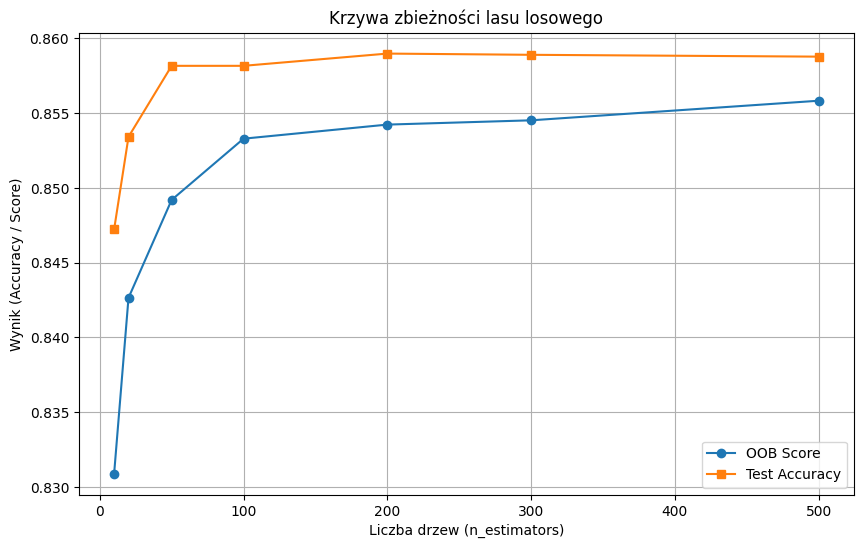

In [50]:
n_estimators_list = [10, 20, 50, 100, 200, 300, 500]
oob_scores = []
test_scores = []

rf = RandomForestClassifier(
    warm_start=True, 
    oob_score=True, 
    random_state=42, 
    n_jobs=-1
)

for n in n_estimators_list:
    rf.n_estimators = n
    rf.fit(X_train_preproc, y_train)
    oob_scores.append(rf.oob_score_)
    y_pred = rf.predict(X_test_preproc)
    test_scores.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(10, 6))
plt.plot(n_estimators_list, oob_scores, 'o-', label='OOB Score')
plt.plot(n_estimators_list, test_scores, 's-', label='Test Accuracy')
plt.xlabel('Liczba drzew (n_estimators)')
plt.ylabel('Wynik (Accuracy / Score)')
plt.title('Krzywa zbieżności lasu losowego')
plt.legend()
plt.grid(True)
plt.show()

Przy małej liczbie drzew las jest niestabilny i błądzi. Powyżej 100 drzew obie linie stają się niemal poziome - moment zbieżności. Oznacza to, że dodawanie kolejnych drzew do lasu przestało wnosić nowe informacje.

### Wpływ max-features

In [51]:
max_features_options = [1, 2, 4, 'sqrt', 'log2', 0.5, None]
results_mf = []

for mf in max_features_options:
    rf_mf = RandomForestClassifier(
        n_estimators=200,
        max_features=mf,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )
    
    rf_mf.fit(X_train_preproc, y_train)
    oob_res = rf_mf.oob_score_
    test_acc = rf_mf.score(X_test_preproc, y_test)
    
    results_mf.append({
        'max_features': str(mf),
        'OOB Score': round(oob_res, 4),
        'Test Accuracy': round(test_acc, 4),
        'Difference': round(test_acc - oob_res, 4)
    })

df_mf_comparison = pd.DataFrame(results_mf)
display(df_mf_comparison)

,max_features,OOB Score,Test Accuracy,Difference
0,1,0.8534,0.8579,0.0045
1,2,0.8548,0.8594,0.0046
2,4,0.8557,0.8583,0.0026
3,sqrt,0.8542,0.8590,0.0048
4,log2,0.8542,0.8590,0.0048
5,0.5,0.8538,0.8573,0.0036
6,None,0.8495,0.8547,0.0052


Najlepsze wyniki zostały uzyskane dla max_features={2,4,sqrt,log2}. Nie powinniśmy używać skrajnych wartości, ponieważ zbyt małe wartości powodują że drzewa przy podziale widzą tylko 1 losową cechę, z kolei zbyt duże wartośći powodują, że stają się silnie skorelowane i identyczne.

### Optymalizacja bayesowska

In [53]:
import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5, 0.8]),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 30),
    }
    
    rf = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    
    pipeline = Pipeline([
        ('preproc', preproc),
        ('rf', rf)
    ])
    
    score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='balanced_accuracy').mean()
    return score

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=15)

print(f"Najlepszy wynik (Balanced Accuracy): {study.best_value:.4f}")
print("Najlepsze parametry:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-04-22 19:10:56,686] A new study created in memory with name: no-name-ed0b99e0-36c2-4849-b50a-fd8f54bf6e3f
[I 2026-04-22 19:11:01,032] Trial 0 finished with value: 0.7633727758258486 and parameters: {'n_estimators': 200, 'max_depth': 29, 'max_features': 'sqrt', 'min_samples_leaf': 18, 'min_samples_split': 19}. Best is trial 0 with value: 0.7633727758258486.
[I 2026-04-22 19:11:07,800] Trial 1 finished with value: 0.6604051478422072 and parameters: {'n_estimators': 400, 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 7, 'min_samples_split': 17}. Best is trial 0 with value: 0.7633727758258486.
[I 2026-04-22 19:11:12,685] Trial 2 finished with value: 0.7540201669780005 and parameters: {'n_estimators': 250, 'max_depth': 11, 'max_features': 'sqrt', 'min_samples_leaf': 16, 'min_samples_split': 7}. Best is trial 0 with value: 0.7633727758258486.
[I 2026-04-22 19:11:19,484] Trial 3 finished with value: 0.7709939043567365 and parameters: {'n_estimators': 300, 'max_depth': 19,

Najlepszy wynik (Balanced Accuracy): 0.7757
Najlepsze parametry:
  n_estimators: 50
  max_depth: 30
  max_features: 0.3
  min_samples_leaf: 2
  min_samples_split: 30


### Random Forest vs HistGradientBoostingClassifier

In [54]:
dt_ccp = grid_search_ccp.best_estimator_
best_rf_params = study.best_params
rf_optuna = Pipeline([
    ('preproc', preproc),
    ('rf', RandomForestClassifier(**best_rf_params, random_state=42, n_jobs=-1))
])
hgb = Pipeline([
    ('preproc', preproc),
    ('hgb', HistGradientBoostingClassifier(max_iter=300, random_state=42))
])
def get_metrics(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    f1 = f1_score(y_test, test_pred, pos_label=model.classes_[1])
    
    return {
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy': round(test_acc, 4),
        'F1 Score (test)': round(f1, 4),
        'Overfit Gap': round(train_acc - test_acc, 4)
    }

comparison_data = {
    'Decision Tree (CCP)': get_metrics(dt_ccp, X_train, y_train, X_test, y_test),
    'Random Forest (Optuna)': get_metrics(rf_optuna, X_train, y_train, X_test, y_test),
    'HistGradientBoosting': get_metrics(hgb, X_train, y_train, X_test, y_test)
}

final_df = pd.DataFrame(comparison_data).T
display(final_df)

,Train Accuracy,Test Accuracy,F1 Score (test),Overfit Gap
Decision Tree (CCP),0.8604,0.8561,0.6784,0.0043
Random Forest (Optuna),0.8992,0.8636,0.6815,0.0356
HistGradientBoosting,0.8872,0.8723,0.7074,0.0149


Najwyższe wyniki (Test Acc i F1) uzyskał HistGradientBoosting. Cena: utrata interpretowalności względem DT, złożoność obliczeniowa.